In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../files/train.csv')
test_df = pd.read_csv('../files/test.csv')

In [6]:
# columns
train_df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [20]:
# dimension
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [21]:
# check if dataset contains missing data

print("Train df\n",train_df.isna().sum())
print("\nTest df\n",test_df.isna().sum())

Train df
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test df
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [31]:
# Identify the unique values of the categorical features (Sex, Embarked)
print(train_df['Sex'].unique())
print(train_df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


In [51]:
# Get the main statistics of numerical features
train_df.describe()
# analisar estes dados tipo media de survived

# train_df.describe(include=['O'])

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


   Pclass  Not Survived  Survived  Chance of Surviving  \
0       1            80       136             0.629630   
1       2            97        87             0.472826   
2       3           372       119             0.242363   

   Chance of Not Surviving  
0                 0.370370  
1                 0.527174  
2                 0.757637  


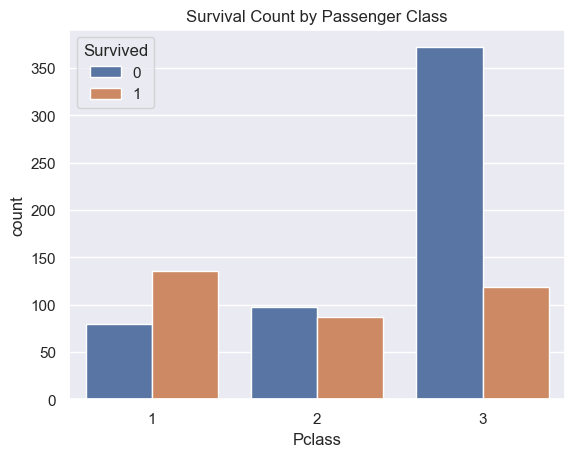

In [191]:
# number of survivors by Pclass
# survival_count_by_class = train_df.groupby(['Pclass', 'Survived']).size().unstack()
# survival_count_by_class.columns = ['Not Survived', 'Survived']
# 
# survival_chance_by_class = train_df.groupby('Pclass')['Survived'].mean().reset_index()
# survival_chance_by_class['Chance of Not Surviving'] = 1 - survival_chance_by_class['Survived']
# survival_chance_by_class.columns = ['Pclass', 'Chance of Surviving', 'Chance of Not Surviving']
# 
# merged_table = pd.merge(survival_count_by_class, survival_chance_by_class, on='Pclass')
# print(merged_table)
# 
# # chart
# sns.countplot(x='Pclass', hue='Survived', data=train_df)
# plt.title('Survival Count by Passenger Class')
# plt.show()

# Most passengers in Pclass=1 survived

      Sex  Non-Survived  Survived  Chance of Surviving  \
0  female            81       233             0.742038   
1    male           468       109             0.188908   

   Chance of Not Surviving  
0                 0.257962  
1                 0.811092  


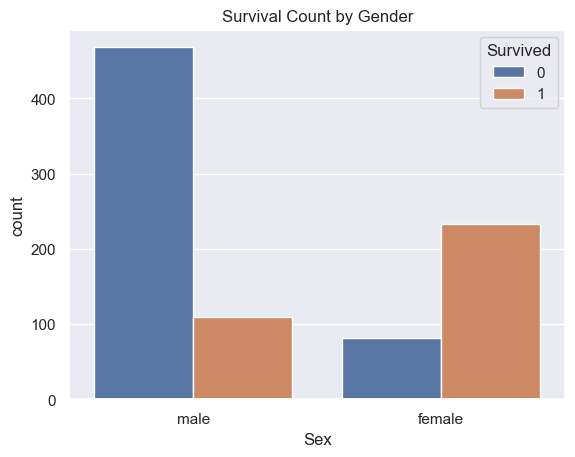

In [194]:
# # number of survivors by gender
# survival_count_by_sex = train_df.groupby(['Sex', 'Survived']).size().unstack()
# survival_count_by_sex.columns = ['Non-Survived', 'Survived']
# 
# survival_chance_by_sex = train_df.groupby('Sex')['Survived'].mean().reset_index()
# survival_chance_by_sex['Chance of Not Surviving'] = 1 - survival_chance_by_sex['Survived']
# survival_chance_by_sex.columns = ['Sex', 'Chance of Surviving', 'Chance of Not Surviving']
# 
# merged_table = pd.merge(survival_count_by_sex, survival_chance_by_sex, on='Sex')
# print(merged_table)
# 
# # chart
# sns.countplot(x='Sex', hue='Survived', data=train_df)
# plt.title('Survival Count by Gender')
# plt.show()

# Female passengers had much better survival rate than males.

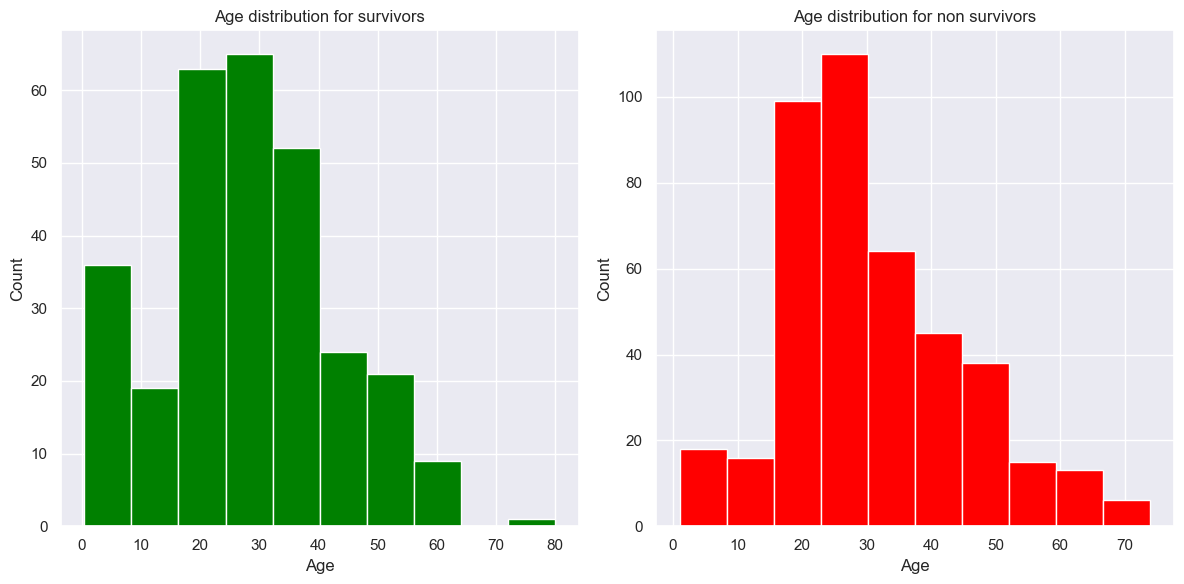

In [202]:
# survivors and non survivors by age
survived_df = train_df[train_df['Survived'] == 1][['Age']]
not_survived_df = train_df[train_df['Survived'] == 0][['Age']]

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.hist(survived_df['Age'].dropna(), color='green')
plt.title('Age distribution for survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(not_survived_df['Age'].dropna(), color='red')
plt.title('Age distribution for non survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


# Most passengers are in 15-35 age range.
# Children had high survival rate

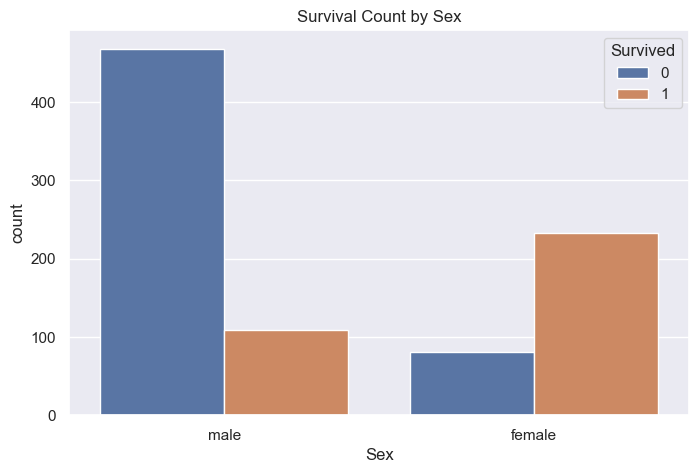

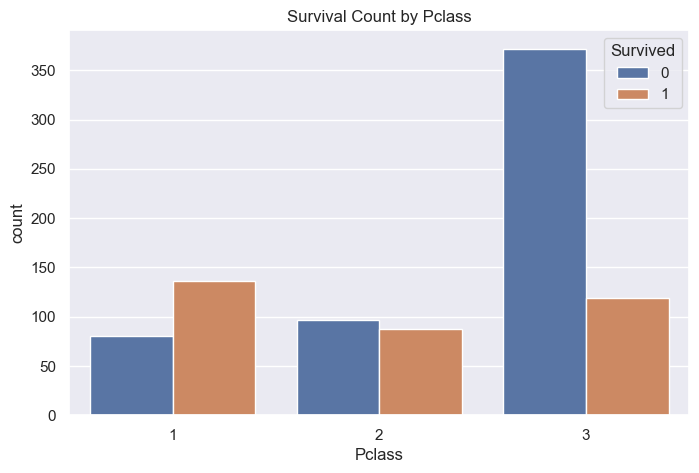

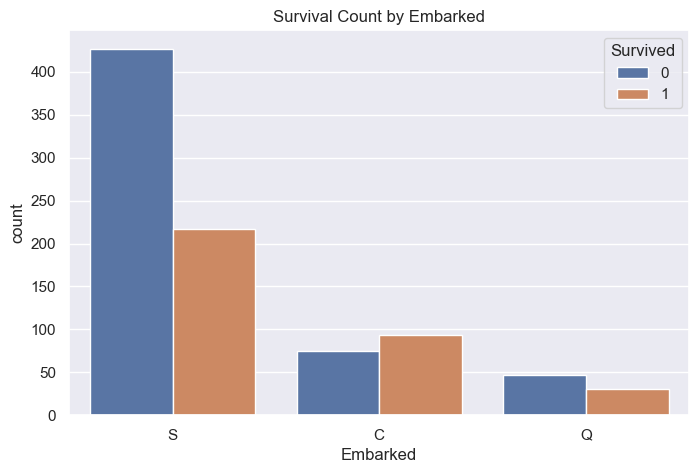

In [198]:
# Create plots for each categorical feature
categorical_features = ['Sex', 'Pclass', 'Embarked']

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Survived', data=train_df)
    plt.title('Survival Count by ' + feature)
    plt.show()

# Female passengers had much better survival rate than males.
# Most passengers in Pclass=1 survived

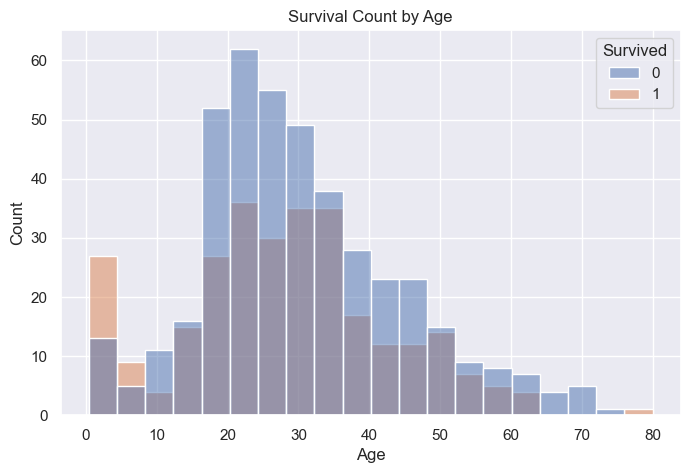

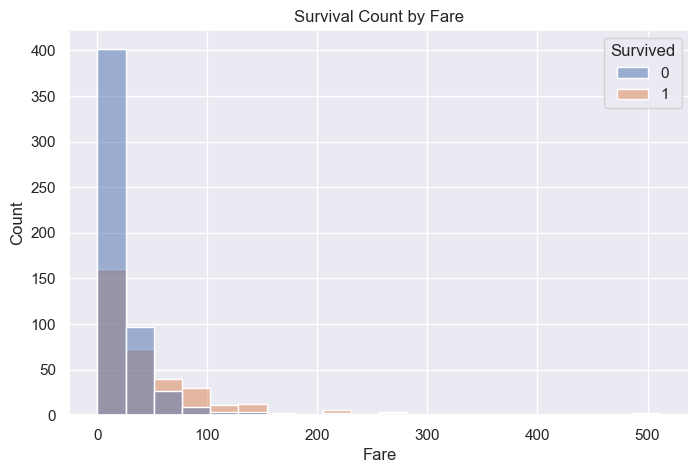

In [211]:
# Create subplots for each numerical feature
numerical_features = ['Age', 'Fare']

for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train_df, x=feature, hue='Survived', bins=20)
    plt.title('Survival Count by ' + feature)
    plt.show()


In [219]:
# para cada valor de embark, tentar perceber se existe alguma relacao com sex, pclass, survived
embark_values = []

for embark in train_df['Embarked'].unique():
    if pd.notnull(embark):
        embark_values.append(embark)

# sns.barplot(x=embark_values, y='Sex', hue='Survived')






# grid = sns.FacetGrid(train_df, col='Embarked')
# grid = sns.FacetGrid(train_df, row='Embarked', size=2.2, aspect=1.6)
# grid.map(sns.pointplot, 'Pclass', 'Survived', 'Sex', palette='deep')
# grid.add_legend()